# Test New Pipeline Features

Quick validation of the refactored pipeline components:
1. **Galactic extinction** (IrsaDust)
2. **ALeRCE direct DB** (PostgreSQL)
3. **Villar SPM** peak estimates
4. **NED redshifts**
5. **Extinction + NED combined**
6. **End-to-end** pipeline with all features
7. **Cache verification**
8. **Light curves** with Villar fits and peak markers
9. **Peak mag vs peak MJD** diagnostic plots

In [1]:
import sys, os
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
# Ensure project root is on path
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working directory:', os.getcwd())
sys.path.insert(0, os.getcwd())

Working directory: /Users/christopherstubbs/Desktop/projects/RubinAlerts


## 1. Galactic Extinction

Query IRSA dust maps for extinction at DDF coordinates.
COSMOS is at high galactic latitude so extinction should be low (~0.05-0.08 in g).

In [2]:
from utils.extinction import get_extinction, get_extinction_batch, correct_magnitude
import pandas as pd

# Test single coordinate — COSMOS DDF center
ext_cosmos = get_extinction(150.11, 2.23)
print('COSMOS extinction (A_SFD by band):')
for band, a_val in sorted(ext_cosmos.items()):
    print(f'  {band}: {a_val:.4f} mag')

print()
# Test extinction correction
raw_mag = 20.5
corrected = correct_magnitude(raw_mag, ext_cosmos.get('r', 0))
print(f'Example: raw mag = {raw_mag}, A_r = {ext_cosmos.get("r", 0):.4f}')
print(f'  Corrected mag = {corrected:.4f}')

COSMOS extinction (A_SFD by band):
  g: 0.0690 mag
  i: 0.0380 mag
  r: 0.0500 mag
  u: 0.0940 mag
  z: 0.0270 mag

Example: raw mag = 20.5, A_r = 0.0500
  Corrected mag = 20.4500


In [3]:
# Test batch extinction on all DDF fields
from core.ddf_fields import DDF_FIELDS

ddf_df = pd.DataFrame(DDF_FIELDS)
print('DDF fields:')
display(ddf_df)

print('\nQuerying extinction for all DDFs...')
ddf_ext = get_extinction_batch(ddf_df)
print('\nExtinction values:')
display(ddf_ext[['name', 'ra', 'dec', 'A_u', 'A_g', 'A_r', 'A_i', 'A_z']])

DDF fields:


,name,ra,dec
0,COSMOS,150.11,2.23
1,XMM-LSS,35.57,-4.82
2,ECDFS,52.98,-28.12
3,ELAIS-S1,9.45,-44.02
4,EDFS_a,58.90,-49.32
5,EDFS_b,63.60,-47.60
6,M49,187.44,8.00



Querying extinction for all DDFs...

Extinction values:


,name,ra,dec,A_u,A_g,A_r,A_i,A_z
0,COSMOS,150.11,2.23,0.094,0.069,0.050,0.038,0.027
1,XMM-LSS,35.57,-4.82,0.129,0.095,0.069,0.052,0.037
2,ECDFS,52.98,-28.12,0.043,0.032,0.023,0.017,0.012
3,ELAIS-S1,9.45,-44.02,0.041,0.030,0.022,0.017,0.012
4,EDFS_a,58.90,-49.32,0.031,0.023,0.016,0.012,0.009
5,EDFS_b,63.60,-47.60,0.070,0.052,0.037,0.028,0.020
6,M49,187.44,8.00,0.115,0.085,0.061,0.047,0.033


## 2. ALeRCE Direct Database Access

Connect to ALeRCE's read-only PostgreSQL database and query SN candidates.

In [4]:
from broker_clients.alerce_db_client import AlerceDBClient

db = AlerceDBClient()
print(f'psycopg2 available: {db.available}')

if db.available:
    db.connect()
    print('Connected to ALeRCE database')
else:
    print('Install psycopg2-binary: pip install psycopg2-binary')

psycopg2 available: True


Connected to ALeRCE database


In [5]:
# Query SN Ia candidates — use P>0.3 threshold since ALeRCE lc_classifier
# gives SNIa lower probabilities than SLSN (no SNIa have P>0.8 as top class)
if db.available:
    candidates = db.query_sn_candidates(min_prob=0.3)
    print(f'SN candidates with P > 0.3: {len(candidates)}')
    
    # Show class distribution
    top = candidates[candidates['ranking'] == 1]
    print(f'\nTop-ranked class distribution:')
    print(top['class_name'].value_counts().to_string())
    
    # Show top SNIa
    snia = candidates[candidates['class_name'] == 'SNIa'].copy()
    snia_top = snia[snia['ranking'] == 1].sort_values('probability', ascending=False)
    print(f'\nTop 10 SNIa candidates (ranking=1):')
    display(snia_top[['oid', 'meanra', 'meandec', 'ndet', 'class_name', 'probability']].head(10))
    
    # Save a few OIDs for later tests
    test_oids = snia_top['oid'].head(5).tolist()
    print(f'\nTest OIDs: {test_oids}')

SN candidates with P > 0.3: 50000

Top-ranked class distribution:
class_name
SNIa              1786
SNIbc              631
SLSN               511
SNII               377
AGN                 31
QSO                  7
YSO                  5
Blazar               5
LPV                  4
Periodic-Other       3
RRL                  1
CV/Nova              1

Top 10 SNIa candidates (ranking=1):


,oid,meanra,meandec,ndet,class_name,probability
7690,ZTF19aavounq,227.491420,14.518140,28,SNIa,0.702
34514,ZTF19aclljyq,26.189246,7.164697,18,SNIa,0.700
12579,ZTF19abahvdh,232.864384,7.095238,25,SNIa,0.698
47998,ZTF20aaljgcp,213.993535,68.297612,41,SNIa,0.694
47330,ZTF20aakbtyz,175.579198,44.962024,38,SNIa,0.692
45917,ZTF20aahptds,195.221141,62.795956,71,SNIa,0.680
33173,ZTF19achejoc,20.913037,7.119257,22,SNIa,0.676
12737,ZTF19abakjao,209.030012,37.564347,20,SNIa,0.670
42992,ZTF20aaeopvv,17.344253,21.724097,22,SNIa,0.662
48840,ZTF20aamgdkb,174.664008,67.589659,41,SNIa,0.662



Test OIDs: ['ZTF19aavounq', 'ZTF19aclljyq', 'ZTF19abahvdh', 'ZTF20aaljgcp', 'ZTF20aakbtyz']


In [6]:
# Query full probabilities for test objects
if db.available and test_oids:
    probs = db.query_probabilities(test_oids)
    print(f'Probabilities for {len(probs)} objects:')
    # Show SN-related columns
    sn_cols = [c for c in probs.columns if 'SN' in c or c in ('oid', 'top_class')]
    display(probs[sn_cols])

Probabilities for 5 objects:


,oid,prob_SLSN,prob_SNII,prob_SNIa,prob_SNIbc,top_class
0,ZTF19aavounq,0.048,0.044,0.702,0.206,SNIa
1,ZTF19abahvdh,0.016,0.058,0.698,0.228,SNIa
2,ZTF19aclljyq,0.050,0.078,0.700,0.172,SNIa
3,ZTF20aakbtyz,0.040,0.078,0.692,0.190,SNIa
4,ZTF20aaljgcp,0.026,0.066,0.694,0.214,SNIa


In [7]:
# Query PS1 host galaxy data
if db.available and test_oids:
    ps1 = db.query_ps1_host(test_oids)
    print(f'PS1 host data for {len(ps1)} objects:')
    display(ps1)

PS1 host data for 5 objects:


,oid,sgmag1,srmag1,simag1,szmag1,sgscore1,g_r_host,r_i_host
0,ZTF19aavounq,19.2276,18.6568,18.6566,18.3053,0.036292,0.5708,0.0002
1,ZTF19abahvdh,21.4309,21.0165,20.9563,20.8663,0.006042,0.4144,0.0602
2,ZTF19aclljyq,19.0141,18.9657,18.5503,18.6879,0.001250,0.0484,0.4154
3,ZTF20aakbtyz,-999.0000,-999.0000,19.1060,19.3554,0.500000,0.0000,-1018.1060
4,ZTF20aaljgcp,19.6006,18.8742,18.6250,18.2266,0.016917,0.7264,0.2492


## 3. Villar SPM Features

Fetch precomputed SPM parameters from ALeRCE and extract peak estimates.

In [8]:
from core.peak_fitting import villar_flux, villar_peak_from_params, extract_villar_peaks
import numpy as np

if db.available and test_oids:
    # Get SPM features
    features = db.query_features(test_oids, prefix='SPM')
    print(f'SPM features for {len(features)} objects:')
    print(f'Columns: {list(features.columns)}')
    display(features.head())
    
    # Build firstmjd lookup from candidates
    firstmjd_lookup = dict(zip(snia_top['oid'], snia_top['firstmjd']))
    
    # Extract peak estimates
    if len(features) > 0:
        villar_peaks = extract_villar_peaks(features, firstmjd_lookup)
        print(f'\nVillar peak estimates for {len(villar_peaks)} objects:')
        for oid, bands in villar_peaks.items():
            for band, result in bands.items():
                print(f'  {oid} [{band}]: peak_mjd={result["peak_mjd"]:.2f}, '
                      f'peak_mag={result["peak_mag"]:.2f}, status={result["status"]}')

SPM features for 5 objects:
Columns: ['oid', 'SPM_A_1', 'SPM_A_2', 'SPM_beta_1', 'SPM_beta_2', 'SPM_chi_1', 'SPM_chi_2', 'SPM_gamma_1', 'SPM_gamma_2', 'SPM_t0_1', 'SPM_t0_2', 'SPM_tau_fall_1', 'SPM_tau_fall_2', 'SPM_tau_rise_1', 'SPM_tau_rise_2']


name_fid,oid,SPM_A_1,SPM_A_2,SPM_beta_1,SPM_beta_2,SPM_chi_1,SPM_chi_2,SPM_gamma_1,SPM_gamma_2,SPM_t0_1,SPM_t0_2,SPM_tau_fall_1,SPM_tau_fall_2,SPM_tau_rise_1,SPM_tau_rise_2
0,ZTF19aavounq,0.247714,0.215291,0.786993,0.564706,0.053490,0.105685,27.464623,23.262360,6.310785,6.689414,14.273140,32.054708,3.236978,3.402180
1,ZTF19abahvdh,0.249661,0.258165,0.361050,0.580508,0.054587,0.120505,17.062072,19.794919,2.824984,4.817869,12.768163,32.156988,2.927568,4.069782
2,ZTF19aclljyq,0.205066,0.264130,0.048838,0.508744,0.599744,0.047813,13.439379,16.680834,1.913288,5.765887,15.033169,38.512001,3.165755,3.799374
3,ZTF20aakbtyz,0.148122,0.177254,0.308374,0.561269,0.034575,0.025669,17.425427,18.677828,4.294892,4.542493,13.370190,42.747820,2.490595,3.582310
4,ZTF20aaljgcp,0.132403,0.169476,0.091747,0.001240,0.071396,0.067764,13.087945,1.334225,3.513537,2.006236,10.567139,21.919957,2.431521,3.369522



Villar peak estimates for 5 objects:
  ZTF19aavounq [g]: peak_mjd=58666.05, peak_mag=19.59, status=ok
  ZTF19aavounq [r]: peak_mjd=58662.22, peak_mag=18.97, status=ok
  ZTF19abahvdh [g]: peak_mjd=58672.06, peak_mag=18.40, status=ok
  ZTF19abahvdh [r]: peak_mjd=58676.79, peak_mag=18.82, status=ok
  ZTF19aclljyq [g]: peak_mjd=58803.55, peak_mag=18.19, status=ok
  ZTF19aclljyq [r]: peak_mjd=58810.64, peak_mag=18.63, status=ok
  ZTF20aakbtyz [g]: peak_mjd=58897.17, peak_mag=18.87, status=ok
  ZTF20aakbtyz [r]: peak_mjd=58898.67, peak_mag=19.18, status=ok
  ZTF20aaljgcp [g]: peak_mjd=58897.09, peak_mag=18.70, status=ok
  ZTF20aaljgcp [r]: peak_mjd=58883.83, peak_mag=18.89, status=ok


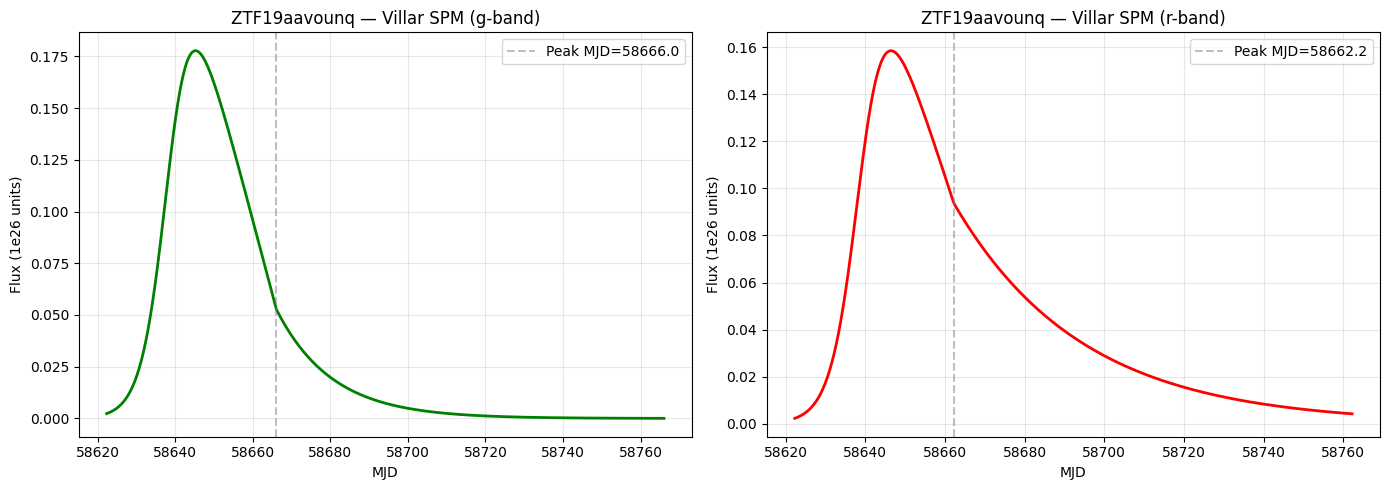

In [9]:
# Plot the Villar model for one object
import matplotlib.pyplot as plt

if db.available and test_oids and len(features) > 0:
    # Pick first object with features
    test_oid = features['oid'].iloc[0]
    row = features[features['oid'] == test_oid].iloc[0]
    firstmjd = firstmjd_lookup.get(test_oid, 59000)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for fid, band, color, ax in [(1, 'g', 'green', axes[0]), (2, 'r', 'red', axes[1])]:
        sfx = f'_{fid}'
        A = row.get(f'SPM_A{sfx}', np.nan)
        t0 = row.get(f'SPM_t0{sfx}', np.nan)
        beta = row.get(f'SPM_beta{sfx}', np.nan)
        gamma = row.get(f'SPM_gamma{sfx}', np.nan)
        tau_rise = row.get(f'SPM_tau_rise{sfx}', np.nan)
        tau_fall = row.get(f'SPM_tau_fall{sfx}', np.nan)
        
        if np.isnan(A):
            ax.text(0.5, 0.5, f'No SPM data for {band}-band', 
                    transform=ax.transAxes, ha='center')
            continue
            
        mjd_grid = np.linspace(firstmjd - 10, firstmjd + t0 + gamma + 100, 500)
        flux = villar_flux(mjd_grid, firstmjd, A, t0, beta, gamma, tau_rise, tau_fall)
        
        ax.plot(mjd_grid, flux, '-', color=color, linewidth=2)
        peak_mjd = firstmjd + t0 + gamma
        ax.axvline(peak_mjd, color='gray', linestyle='--', alpha=0.5, label=f'Peak MJD={peak_mjd:.1f}')
        ax.set_xlabel('MJD')
        ax.set_ylabel('Flux (1e26 units)')
        ax.set_title(f'{test_oid} — Villar SPM ({band}-band)')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 4. NED Redshift Lookups

Query NED for spectroscopic host galaxy redshifts near our test objects.

In [10]:
from utils.ned_query import query_ned_redshift, query_ned_batch

# Test single coordinate — well-known galaxy cluster in COSMOS field
result = query_ned_redshift(150.11, 2.23, radius_arcsec=60)
if result:
    print(f'NED result near COSMOS center:')
    print(f'  Name: {result["ned_name"]}')
    print(f'  Redshift: {result["redshift"]:.4f}')
    print(f'  Distance modulus: {result["distmod"]:.2f} mag')
    print(f'  Separation: {result["separation_arcsec"]:.1f} arcsec')
else:
    print('No NED source with redshift found near COSMOS center')

NED result near COSMOS center:
  Name: COSMOS2015 0611653
  Redshift: 5.8680
  Distance modulus: 48.81 mag
  Separation: 0.0 arcsec


In [11]:
# Batch NED lookup for test objects
if db.available and test_oids:
    test_coords = snia_top[snia_top['oid'].isin(test_oids)][['oid', 'meanra', 'meandec']].copy()
    test_coords = test_coords.rename(columns={'meanra': 'ra', 'meandec': 'dec'})
    
    print(f'Querying NED for {len(test_coords)} objects...')
    ned_results = query_ned_batch(test_coords)
    
    print('\nNED results:')
    display(ned_results[['oid', 'ra', 'dec', 'ned_redshift', 'ned_distmod', 'ned_name', 'ned_sep_arcsec']])

Querying NED for 5 objects...



NED results:


,oid,ra,dec,ned_redshift,ned_distmod,ned_name,ned_sep_arcsec
7690,ZTF19aavounq,227.491420,14.518140,0.076341,37.685050,SN 2019gel,0.001
34514,ZTF19aclljyq,26.189246,7.164697,NaN,NaN,,NaN
12579,ZTF19abahvdh,232.864384,7.095238,0.077400,37.716607,SN 2019hxb,0.003
47998,ZTF20aaljgcp,213.993535,68.297612,0.080232,37.799019,SN 2020buv,0.001
47330,ZTF20aakbtyz,175.579198,44.962024,0.091664,38.105774,SN 2020bjg,0.001


## 5. Extinction + NED Combined

For objects with both extinction and redshift, compute absolute magnitudes.

In [12]:
if db.available and test_oids:
    # Combine extinction and NED data
    combined = test_coords.copy()
    
    # Add extinction
    print('Querying extinction...')
    combined = get_extinction_batch(combined)
    
    # Add NED redshifts (already in ned_results)
    combined['ned_redshift'] = ned_results['ned_redshift'].values
    combined['ned_distmod'] = ned_results['ned_distmod'].values
    
    print('\nCombined data:')
    display(combined[['oid', 'ra', 'dec', 'A_g', 'A_r', 'ned_redshift', 'ned_distmod']])
    
    # Example: if we had a peak mag of 20.0 in r-band
    example_mag = 20.0
    for _, row in combined.iterrows():
        if pd.notna(row['A_r']) and pd.notna(row['ned_distmod']):
            m_corrected = example_mag - row['A_r']
            M_abs = m_corrected - row['ned_distmod']
            print(f"\n{row['oid']}: m_r={example_mag} -> m_corrected={m_corrected:.3f} "
                  f"-> M_abs={M_abs:.2f} (z={row['ned_redshift']:.4f})")
            if -20.5 < M_abs < -18.0:
                print('  ^ Consistent with SN Ia absolute magnitude range!')

Querying extinction...



Combined data:


,oid,ra,dec,A_g,A_r,ned_redshift,ned_distmod
7690,ZTF19aavounq,227.491420,14.518140,0.127,0.092,0.076341,37.685050
34514,ZTF19aclljyq,26.189246,7.164697,0.123,0.089,NaN,NaN
12579,ZTF19abahvdh,232.864384,7.095238,0.152,0.110,0.077400,37.716607
47998,ZTF20aaljgcp,213.993535,68.297612,0.074,0.053,0.080232,37.799019
47330,ZTF20aakbtyz,175.579198,44.962024,0.085,0.061,0.091664,38.105774



ZTF19aavounq: m_r=20.0 -> m_corrected=19.908 -> M_abs=-17.78 (z=0.0763)

ZTF19abahvdh: m_r=20.0 -> m_corrected=19.890 -> M_abs=-17.83 (z=0.0774)

ZTF20aaljgcp: m_r=20.0 -> m_corrected=19.947 -> M_abs=-17.85 (z=0.0802)

ZTF20aakbtyz: m_r=20.0 -> m_corrected=19.939 -> M_abs=-18.17 (z=0.0917)
  ^ Consistent with SN Ia absolute magnitude range!


## 6. End-to-End Pipeline Test

Run the full pipeline on one DDF field with all new features enabled.

In [13]:
from supernova_monitor import SupernovaMonitor
from core.ddf_fields import DDF_FIELDS

# Use just COSMOS for a quick test
cosmos = [f for f in DDF_FIELDS if f['name'] == 'COSMOS']

monitor = SupernovaMonitor(
    cache_dir='./cache/data',
    use_alerce_db=True,
    apply_extinction=True,
    query_ned=True,
)

print('Pipeline initialized with all new features')
print(f'Brokers available: {list(monitor.brokers.keys())}')

2026-02-28 18:58:31,195 - cache.alert_cache - INFO - Initialized cache database at ./cache/data/alerts_cache.db


2026-02-28 18:58:31,197 - cache.alert_cache - INFO - Initialized cache database at ./cache/data/alerts_cache.db


2026-02-28 18:58:31,197 - cache.alert_cache - INFO - Initialized cache database at ./cache/data/alerts_cache.db


2026-02-28 18:58:31,206 - core.variable_screen - INFO - Loaded 1937 variables from COSMOS_variables.csv


2026-02-28 18:58:31,212 - core.variable_screen - INFO - Loaded 1587 variables from XMM-LSS_variables.csv


...

2026-02-28 18:58:31,305 - broker_clients.alerce_client - INFO - ALeRCE client initialized successfully (survey=ztf)


2026-02-28 18:58:31,305 - supernova_monitor - INFO - ALeRCE (ZTF) client initialized (db=True)


2026-02-28 18:58:31,306 - broker_clients.alerce_client - INFO - ALeRCE client initialized successfully (survey=lsst)


2026-02-28 18:58:31,307 - supernova_monitor - INFO - ALeRCE (LSST) client initialized


Pipeline initialized with all new features
Brokers available: ['ANTARES', 'ALeRCE', 'ALeRCE-LSST']


In [14]:
# Run pipeline on COSMOS only, with relaxed thresholds for testing
results = monitor.run_full_pipeline(
    min_ia_probability=0.3,
    days_back=90,
    limit=50,
    ddf_fields=cosmos,
    require_rubin=False,
    atlas_enrichment=False,  # skip ATLAS to keep test fast
)

if results is not None and len(results) > 0:
    print(f'\nPipeline returned {len(results)} candidates')
    
    # Check which new columns are present
    new_cols = [c for c in results.columns if c.startswith(('A_', 'ned_'))]
    print(f'New columns: {new_cols}')
    
    # Show a few rows with new data
    show_cols = ['unique_id', 'ra', 'dec', 'mean_ia_prob', 'num_brokers']
    show_cols += [c for c in new_cols if c in results.columns]
    display(results[show_cols].head(10))
else:
    print('No candidates returned (check broker connectivity)')

2026-02-28 18:58:48,260 - supernova_monitor - INFO - ============================================================


2026-02-28 18:58:48,261 - supernova_monitor - INFO - Starting SuperNova Monitoring Pipeline


2026-02-28 18:58:48,261 - supernova_monitor - INFO - Time: 2026-02-28T18:58:48.261856


2026-02-28 18:58:48,262 - supernova_monitor - INFO - DDFs: COSMOS


2026-02-28 18:58:48,262 - supernova_monitor - INFO - Parameters: P(Ia) >= 0.3, days_back=90, limit=50, require_rubin=False, elliptical_filter=False, atlas_enrichment=False


...

2026-02-28 18:58:52,457 - supernova_monitor - INFO - ============================================================


2026-02-28 18:58:52,457 - supernova_monitor - INFO - FINAL: 76 Type Ia candidates


2026-02-28 18:58:52,457 - supernova_monitor - INFO - ============================================================



Pipeline returned 76 candidates
New columns: ['A_u', 'A_g', 'A_r', 'A_i', 'A_z', 'ned_redshift', 'ned_distmod', 'ned_name', 'ned_sep_arcsec']


,unique_id,ra,dec,mean_ia_prob,num_brokers,A_u,A_g,A_r,A_i,A_z,ned_redshift,ned_distmod,ned_name,ned_sep_arcsec
0,149.49365_2.37231,149.493653,2.372306,0.45,1,0.106,0.078,0.057,0.043,0.031,0.495700,42.247444,zCOSMOS 834854,0.111
1,150.16602_2.10977,150.166016,2.109765,0.45,1,0.088,0.065,0.047,0.036,0.025,2.068800,46.089059,COSMOS2015 0531486,0.021
2,149.86064_3.42369,149.860635,3.423690,0.45,1,0.115,0.085,0.061,0.047,0.033,1.061780,44.287134,DESI J149.8577+03.4257,0.213
3,150.99906_2.48992,150.999059,2.489920,0.45,1,0.119,0.088,0.064,0.048,0.034,NaN,NaN,,NaN
4,151.47973_2.40489,151.479734,2.404890,0.35,1,0.222,0.163,0.118,0.090,0.064,NaN,NaN,,NaN
5,150.21591_1.77394,150.215912,1.773942,0.45,1,0.095,0.070,0.051,0.039,0.027,2.166600,46.212567,COSMOS 0522834,0.056
6,150.10708_3.85357,150.107076,3.853568,0.45,1,0.125,0.092,0.066,0.050,0.036,0.057778,37.050902,SDSS J100026.44+035104.2,0.232
7,149.84615_3.85717,149.846154,3.857174,0.45,1,0.132,0.097,0.070,0.053,0.038,NaN,NaN,,NaN
8,151.71209_1.97280,151.712095,1.972802,0.45,1,0.172,0.127,0.092,0.070,0.049,NaN,NaN,,NaN
9,148.50320_2.83809,148.503199,2.838095,0.45,1,0.254,0.187,0.136,0.103,0.073,NaN,NaN,,NaN


In [15]:
# Summary statistics
if results is not None and len(results) > 0:
    print('=== New Feature Coverage ===')
    
    if 'A_g' in results.columns:
        n_ext = results['A_g'].notna().sum()
        print(f'Extinction:  {n_ext}/{len(results)} have A_g values')
        if n_ext > 0:
            print(f'  A_g range: {results["A_g"].min():.4f} - {results["A_g"].max():.4f}')
    
    if 'ned_redshift' in results.columns:
        n_z = results['ned_redshift'].notna().sum()
        print(f'NED redshift: {n_z}/{len(results)} have spectroscopic z')
        if n_z > 0:
            print(f'  z range: {results["ned_redshift"].min():.4f} - {results["ned_redshift"].max():.4f}')
    
    print(f'\nBroker breakdown:')
    print(results['brokers_detected'].value_counts().to_string())

=== New Feature Coverage ===
Extinction:  76/76 have A_g values
  A_g range: 0.0650 - 0.2560
NED redshift: 52/76 have spectroscopic z
  z range: -0.0001 - 2.1666

Broker breakdown:
brokers_detected
ANTARES        50
ALeRCE-LSST    25
ALeRCE          1


## 7. Cache Verification

Check that extinction and NED data were cached in SQLite.

In [16]:
from cache.alert_cache import AlertCache

cache = AlertCache('./cache/data')

# Test extinction cache retrieval (should be instant, no IRSA query)
cached_ext = cache.get_cached_extinction(150.11, 2.23)
if cached_ext:
    print('Cached extinction for COSMOS center:', cached_ext)
else:
    print('No cached extinction (run extinction test first)')

# Test NED cache
cached_ned = cache.get_cached_ned_info(150.11, 2.23)
if cached_ned:
    print('Cached NED info for COSMOS center:', cached_ned)
else:
    print('No cached NED info')

2026-02-28 18:59:25,725 - cache.alert_cache - INFO - Initialized cache database at ./cache/data/alerts_cache.db


Cached extinction for COSMOS center: {'u': 0.094, 'g': 0.069, 'r': 0.05, 'i': 0.038, 'z': 0.027}
No cached NED info


## 8. Light Curves with Villar Fits and Peak Markers

Fetch ZTF light curves from the ALeRCE database, overlay Villar SPM model fits,
and mark the predicted peak epoch with vertical lines.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from core.peak_fitting import villar_flux, extract_villar_peaks
from broker_clients.alerce_db_client import AlerceDBClient

# Reconnect if needed
if not db.available:
    raise RuntimeError('psycopg2 required for this section')
db._ensure_connected()

# Get a sample of well-classified SNIa candidates
candidates = db.query_sn_candidates(min_prob=0.3)
snia = candidates[(candidates['class_name'] == 'SNIa') & (candidates['ranking'] == 1)]
snia = snia.sort_values('probability', ascending=False)

# Take top 12 for a nice grid
n_plot = 12
sample_oids = snia['oid'].head(n_plot).tolist()
print(f'Selected {len(sample_oids)} SNIa candidates for light curve plots')

# Fetch light curves, SPM features
detections = db.query_detections(sample_oids)
features = db.query_features(sample_oids, prefix='SPM')
firstmjd_lookup = dict(zip(snia['oid'], snia['firstmjd']))

# Extract Villar peaks
villar_peaks = extract_villar_peaks(features, firstmjd_lookup)

print(f'Detections: {len(detections)} photometric points')
print(f'SPM features for {len(features)} objects')
print(f'Villar peaks for {len(villar_peaks)} objects')

In [ ]:
# Plot light curves with Villar model fits and peak markers
band_config = {
    1: {'label': 'g', 'color': '#2ca02c', 'peak_ls': '--'},  # green
    2: {'label': 'r', 'color': '#d62728', 'peak_ls': ':'},    # red
}

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for idx, oid in enumerate(sample_oids):
    ax = axes[idx]
    
    # Get this object's detections
    obj_det = detections[detections['oid'] == oid]
    firstmjd = firstmjd_lookup.get(oid, np.nan)
    
    # Get SPM features for this object
    obj_feat = features[features['oid'] == oid]
    has_spm = len(obj_feat) > 0
    if has_spm:
        feat_row = obj_feat.iloc[0]
    
    # Plot each band
    for fid, cfg in band_config.items():
        band_det = obj_det[obj_det['fid'] == fid]
        if len(band_det) == 0:
            continue
        
        # Photometry with error bars
        ax.errorbar(
            band_det['mjd'], band_det['magpsf'],
            yerr=band_det['sigmapsf'],
            fmt='o', ms=4, color=cfg['color'], alpha=0.7,
            label=f'{cfg["label"]}-band ({len(band_det)} pts)',
            capsize=0, elinewidth=0.8,
        )
        
        # Villar SPM model overlay
        if has_spm and not np.isnan(firstmjd):
            sfx = f'_{fid}'
            A = feat_row.get(f'SPM_A{sfx}', np.nan)
            t0 = feat_row.get(f'SPM_t0{sfx}', np.nan)
            beta = feat_row.get(f'SPM_beta{sfx}', np.nan)
            gamma = feat_row.get(f'SPM_gamma{sfx}', np.nan)
            tau_rise = feat_row.get(f'SPM_tau_rise{sfx}', np.nan)
            tau_fall = feat_row.get(f'SPM_tau_fall{sfx}', np.nan)
            
            if not np.isnan(A):
                # Generate model curve over the data range
                mjd_min = max(band_det['mjd'].min() - 15, firstmjd - 10)
                mjd_max = band_det['mjd'].max() + 30
                mjd_grid = np.linspace(mjd_min, mjd_max, 300)
                flux_model = villar_flux(
                    mjd_grid, firstmjd, A, t0, beta, gamma, tau_rise, tau_fall
                )
                # Convert flux to mag: mag = -2.5*log10(flux) + 2.5*26 - 48.6
                with np.errstate(divide='ignore', invalid='ignore'):
                    mag_model = np.where(
                        flux_model > 0,
                        -2.5 * np.log10(flux_model) + 16.4,
                        np.nan,
                    )
                ax.plot(mjd_grid, mag_model, '-', color=cfg['color'],
                        alpha=0.5, linewidth=1.5)
        
        # Peak vertical line
        peaks = villar_peaks.get(oid, {})
        band_peak = peaks.get(cfg['label'])
        if band_peak and band_peak['status'] == 'ok':
            peak_mjd = band_peak['peak_mjd']
            peak_mag = band_peak['peak_mag']
            ax.axvline(peak_mjd, color=cfg['color'], linestyle=cfg['peak_ls'],
                       alpha=0.8, linewidth=1.5,
                       label=f'peak {cfg["label"]}={peak_mag:.1f} @ {peak_mjd:.0f}')
    
    # Formatting
    ax.invert_yaxis()
    ax.set_xlabel('MJD')
    ax.set_ylabel('Magnitude')
    
    # Get P(Ia) for title
    prob = snia[snia['oid'] == oid]['probability'].values
    prob_str = f', P(Ia)={prob[0]:.2f}' if len(prob) > 0 else ''
    ax.set_title(f'{oid}{prob_str}', fontsize=10, fontweight='bold')
    
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.2)

plt.suptitle('ZTF Type Ia SN Candidates — Light Curves with Villar SPM Fits',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Peak Magnitude vs Peak MJD for Type Ia Candidates

Extract Villar peak estimates for a larger sample and plot the predicted
peak apparent magnitude against peak epoch. This is the key diagnostic for
scheduling spectroscopic follow-up: objects near peak and bright enough
for Magellan are highest priority.

In [ ]:
# Extract Villar peaks for a larger SNIa sample
n_sample = 200
sample_oids_lg = snia['oid'].head(n_sample).tolist()
print(f'Fetching SPM features for {len(sample_oids_lg)} SNIa candidates...')

features_lg = db.query_features(sample_oids_lg, prefix='SPM')
firstmjd_lookup_lg = dict(zip(snia['oid'], snia['firstmjd']))
villar_peaks_lg = extract_villar_peaks(features_lg, firstmjd_lookup_lg)

# Build a table of peak estimates
peak_rows = []
for oid, bands in villar_peaks_lg.items():
    prob_val = snia[snia['oid'] == oid]['probability'].values
    p_ia = prob_val[0] if len(prob_val) > 0 else np.nan
    for band, result in bands.items():
        if result['status'] == 'ok':
            peak_rows.append({
                'oid': oid,
                'band': band,
                'peak_mjd': result['peak_mjd'],
                'peak_mag': result['peak_mag'],
                'p_ia': p_ia,
            })

peaks_df = pd.DataFrame(peak_rows)
print(f'Valid peak estimates: {len(peaks_df)} ({peaks_df["oid"].nunique()} objects, '
      f'{len(peaks_df[peaks_df["band"]=="g"])} g-band, '
      f'{len(peaks_df[peaks_df["band"]=="r"])} r-band)')
display(peaks_df.describe())

In [ ]:
# 2D scatter: Peak MJD vs Peak Magnitude for SNIa candidates
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, band, color, marker in [
    (axes[0], 'g', '#2ca02c', 'o'),
    (axes[1], 'r', '#d62728', 's'),
]:
    bdf = peaks_df[peaks_df['band'] == band]
    
    sc = ax.scatter(
        bdf['peak_mjd'], bdf['peak_mag'],
        c=bdf['p_ia'], cmap='viridis', vmin=0.3, vmax=0.75,
        s=50, marker=marker, edgecolors='k', linewidth=0.3, alpha=0.8,
    )
    
    # Mark the "sweet spot" for Magellan follow-up
    ax.axhspan(18.0, 22.0, alpha=0.06, color='blue',
               label='Magellan range (18-22)')
    
    ax.set_xlabel('Peak MJD', fontsize=12)
    ax.set_title(f'{band}-band Peak Estimates ({len(bdf)} objects)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Peak Apparent Magnitude', fontsize=12)
axes[0].invert_yaxis()

# Shared colorbar
cbar = fig.colorbar(sc, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label('P(Ia)', fontsize=11)

plt.suptitle('Villar SPM Peak Estimates for ZTF SNIa Candidates',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nMedian peak mag: g={peaks_df[peaks_df["band"]=="g"]["peak_mag"].median():.1f}, '
      f'r={peaks_df[peaks_df["band"]=="r"]["peak_mag"].median():.1f}')
print(f'MJD range: {peaks_df["peak_mjd"].min():.0f} - {peaks_df["peak_mjd"].max():.0f}')

In [ ]:
# Peak magnitude distributions and g-r color at peak
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Peak mag histograms by band
ax = axes[0]
for band, color, label in [('g', '#2ca02c', 'g-band'), ('r', '#d62728', 'r-band')]:
    mags = peaks_df[peaks_df['band'] == band]['peak_mag']
    ax.hist(mags, bins=25, alpha=0.6, color=color, label=f'{label} (N={len(mags)})',
            edgecolor='k', linewidth=0.5)
ax.set_xlabel('Peak Apparent Magnitude')
ax.set_ylabel('Count')
ax.set_title('Peak Magnitude Distribution')
ax.legend()
ax.grid(True, alpha=0.2)

# Panel 2: g-r color at peak
ax = axes[1]
# Merge g and r peaks per object
g_peaks = peaks_df[peaks_df['band'] == 'g'][['oid', 'peak_mag', 'peak_mjd']].rename(
    columns={'peak_mag': 'peak_g', 'peak_mjd': 'peak_mjd_g'})
r_peaks = peaks_df[peaks_df['band'] == 'r'][['oid', 'peak_mag', 'peak_mjd']].rename(
    columns={'peak_mag': 'peak_r', 'peak_mjd': 'peak_mjd_r'})
gr_df = g_peaks.merge(r_peaks, on='oid', how='inner')
gr_df['g_minus_r'] = gr_df['peak_g'] - gr_df['peak_r']
gr_df['dt_peak'] = gr_df['peak_mjd_r'] - gr_df['peak_mjd_g']  # r peaks later for Ia

ax.hist(gr_df['g_minus_r'], bins=25, alpha=0.7, color='purple',
        edgecolor='k', linewidth=0.5)
ax.axvline(gr_df['g_minus_r'].median(), color='k', linestyle='--',
           label=f'median = {gr_df["g_minus_r"].median():.2f}')
ax.set_xlabel('(g - r) at Peak')
ax.set_ylabel('Count')
ax.set_title(f'Color at Peak (N={len(gr_df)})')
ax.legend()
ax.grid(True, alpha=0.2)

# Panel 3: Time delay between g and r peaks
ax = axes[2]
ax.hist(gr_df['dt_peak'], bins=25, alpha=0.7, color='steelblue',
        edgecolor='k', linewidth=0.5)
ax.axvline(gr_df['dt_peak'].median(), color='k', linestyle='--',
           label=f'median = {gr_df["dt_peak"].median():.1f} d')
ax.axvline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('$\\Delta t_{\\mathrm{peak}}$ (r - g) [days]')
ax.set_ylabel('Count')
ax.set_title('g-to-r Peak Time Delay')
ax.legend()
ax.grid(True, alpha=0.2)

plt.suptitle('SNIa Peak Properties from Villar SPM Fits',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'g-r at peak: median={gr_df["g_minus_r"].median():.2f}, '
      f'std={gr_df["g_minus_r"].std():.2f}')
print(f'Peak time delay (r-g): median={gr_df["dt_peak"].median():.1f} d, '
      f'std={gr_df["dt_peak"].std():.1f} d')